In [26]:
# Cell 1: Imports and Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python version: {sys.version}")

Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
Python version: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]


In [27]:
# Cell 2: Load Extracted Features
FEATURES_DIR = PROJECT_ROOT / "data" / "features"

print("Loading extracted features...")
df_train = pd.read_csv(FEATURES_DIR / "features_train.csv")
df_val = pd.read_csv(FEATURES_DIR / "features_val.csv")
df_test = pd.read_csv(FEATURES_DIR / "features_test.csv")

print(f"\nLoaded datasets:")
print(f"  Train: {df_train.shape}")
print(f"  Val: {df_val.shape}")
print(f"  Test: {df_test.shape}")

# Separate features and labels
X_train = df_train.drop(['label', 'image_path'], axis=1).values
y_train = df_train['label'].values

X_val = df_val.drop(['label', 'image_path'], axis=1).values
y_val = df_val['label'].values

X_test = df_test.drop(['label', 'image_path'], axis=1).values
y_test = df_test['label'].values

feature_names = df_train.drop(['label', 'image_path'], axis=1).columns.tolist()

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"\nOriginal feature count: {len(feature_names)}")

Loading extracted features...

Loaded datasets:
  Train: (3909, 26545)
  Val: (285, 26545)
  Test: (297, 26545)

Feature matrix shapes:
  X_train: (3909, 26543)
  X_val: (285, 26543)
  X_test: (297, 26543)

Original feature count: 26543


In [28]:
# Cell 3: Sanitize Features (NaN/Inf guard)
# NOTE: If feature extraction produced any NaN/Inf (e.g., from older CSVs),
# we sanitize here so scaling/selection doesn't break.

def _nan_inf_counts(x: np.ndarray) -> tuple[int, int, int]:
    nan = int(np.isnan(x).sum())
    posinf = int(np.isposinf(x).sum())
    neginf = int(np.isneginf(x).sum())
    return nan, posinf, neginf

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    nan, posinf, neginf = _nan_inf_counts(arr)
    print(f"Before sanitize: {name} NaN={nan}, +Inf={posinf}, -Inf={neginf}")

X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    nan, posinf, neginf = _nan_inf_counts(arr)
    print(f"After sanitize:  {name} NaN={nan}, +Inf={posinf}, -Inf={neginf}")

Before sanitize: X_train NaN=0, +Inf=0, -Inf=0
Before sanitize: X_val NaN=0, +Inf=0, -Inf=0
Before sanitize: X_test NaN=0, +Inf=0, -Inf=0
After sanitize:  X_train NaN=0, +Inf=0, -Inf=0
After sanitize:  X_val NaN=0, +Inf=0, -Inf=0
After sanitize:  X_test NaN=0, +Inf=0, -Inf=0


In [29]:
# Cell 4: Method 1 - Variance Threshold (BEFORE scaling)
print("="*70)
print("METHOD 1: VARIANCE THRESHOLD (before scaling)")
print("="*70)

# IMPORTANT: Apply VarianceThreshold BEFORE StandardScaler.
# If you standardize first, most features end up with variance ~1, and variance filtering becomes meaningless.
#
# Use threshold=0.0 to drop only truly-constant features (safe default).
# You can increase this slightly (e.g., 1e-6, 1e-4) if you want more aggressive filtering.
threshold = 0.0001
var_selector = VarianceThreshold(threshold=threshold)

n_original = X_train.shape[1]
X_train_var_raw = var_selector.fit_transform(X_train)
X_val_var_raw = var_selector.transform(X_val)
X_test_var_raw = var_selector.transform(X_test)

selected_features_var = [
    feature_names[i]
    for i in range(len(feature_names))
    if var_selector.get_support()[i]
 ]

print(f"\nVariance threshold: {threshold}")
print(f"Features retained: {X_train_var_raw.shape[1]} / {n_original}")
print(f"Features removed: {n_original - X_train_var_raw.shape[1]}")
print(f"Reduction: {(1 - X_train_var_raw.shape[1]/n_original)*100:.2f}%")

# Show variance distribution (computed on the original, unscaled X_train)
variances = var_selector.variances_
print(f"\nVariance statistics (on raw features):")
print(f"  Min variance: {variances.min():.6f}")
print(f"  Max variance: {variances.max():.6f}")
print(f"  Mean variance: {variances.mean():.6f}")
print(f"  Median variance: {np.median(variances):.6f}")

# Now scale AFTER variance filtering (this is what you want for SVM/KNN/MLP/PCA, etc.)
print("\nStandardizing variance-filtered features...")
scaler = StandardScaler()
X_train_var = scaler.fit_transform(X_train_var_raw)
X_val_var = scaler.transform(X_val_var_raw)
X_test_var = scaler.transform(X_test_var_raw)

print(f"\nStandardized stats (train, after variance filter):")
print(f"  Mean: {X_train_var.mean():.6f} (should be ~0)")
print(f"  Std: {X_train_var.std():.6f} (should be ~1)")
print(f"  Min: {X_train_var.min():.4f}")
print(f"  Max: {X_train_var.max():.4f}")

METHOD 1: VARIANCE THRESHOLD (before scaling)

Variance threshold: 0.0001
Features retained: 26514 / 26543
Features removed: 29
Reduction: 0.11%

Variance statistics (on raw features):
  Min variance: 0.000004
  Max variance: 6980.326772
  Mean variance: 0.367123
  Median variance: 0.010588

Standardizing variance-filtered features...

Standardized stats (train, after variance filter):
  Mean: -0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)
  Min: -23.2707
  Max: 40.7130


In [30]:
# Cell 5: Method 2 - SelectKBest with F-statistic
print("="*70)
print("METHOD 2: SELECTKBEST (F-STATISTIC)")
print("="*70)

# Select top K features using ANOVA F-statistic
k_values = [50, 100, 200, 500]
results_fstat = {}

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=min(k, X_train_var.shape[1]))
    X_train_k = selector.fit_transform(X_train_var, y_train)
    
    # Get selected feature names
    selected_mask = selector.get_support()
    selected_features = [selected_features_var[i] for i in range(len(selected_features_var)) 
                        if selected_mask[i]]
    
    # Get feature scores
    scores = selector.scores_
    
    results_fstat[k] = {
        'selector': selector,
        'selected_features': selected_features,
        'scores': scores,
        'n_features': X_train_k.shape[1]
    }
    
    print(f"\nK = {k}:")
    print(f"  Features selected: {X_train_k.shape[1]}")
    print(f"  Score range: [{scores.min():.2f}, {scores.max():.2f}]")
    print(f"  Top 5 features:")
    top_indices = np.argsort(scores)[-5:][::-1]
    for idx in top_indices:
        if idx < len(selected_features_var):
            print(f"    {selected_features_var[idx]}: {scores[idx]:.2f}")

# Use K=100 as default
best_k = 100
fstat_selector = results_fstat[best_k]['selector']
X_train_fstat = fstat_selector.transform(X_train_var)
X_val_fstat = fstat_selector.transform(X_val_var)
X_test_fstat = fstat_selector.transform(X_test_var)
selected_features_fstat = results_fstat[best_k]['selected_features']

print(f"\n✓ Selected K={best_k} for F-statistic method")

METHOD 2: SELECTKBEST (F-STATISTIC)

K = 50:
  Features selected: 50
  Score range: [0.72, 65.33]
  Top 5 features:
    lbp_bin_12: 65.33
    lbp_bin_25: 58.23
    hog_11196: 53.67
    lbp_bin_13: 51.59
    hog_10224: 50.79

K = 100:
  Features selected: 100
  Score range: [0.72, 65.33]
  Top 5 features:
    lbp_bin_12: 65.33
    lbp_bin_25: 58.23
    hog_11196: 53.67
    lbp_bin_13: 51.59
    hog_10224: 50.79

K = 200:
  Features selected: 200
  Score range: [0.72, 65.33]
  Top 5 features:
    lbp_bin_12: 65.33
    lbp_bin_25: 58.23
    hog_11196: 53.67
    lbp_bin_13: 51.59
    hog_10224: 50.79

K = 500:
  Features selected: 500
  Score range: [0.72, 65.33]
  Top 5 features:
    lbp_bin_12: 65.33
    lbp_bin_25: 58.23
    hog_11196: 53.67
    lbp_bin_13: 51.59
    hog_10224: 50.79

✓ Selected K=100 for F-statistic method


In [31]:
# Cell 6: Method 3 - SelectKBest with Mutual Information
print("="*70)
print("METHOD 3: SELECTKBEST (MUTUAL INFORMATION)")
print("="*70)

# Select top K features using mutual information
k = 100
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_mi = mi_selector.fit_transform(X_train_var, y_train)
X_val_mi = mi_selector.transform(X_val_var)
X_test_mi = mi_selector.transform(X_test_var)

selected_mask = mi_selector.get_support()
selected_features_mi = [selected_features_var[i] for i in range(len(selected_features_var)) 
                        if selected_mask[i]]

mi_scores = mi_selector.scores_

print(f"\nK = {k}:")
print(f"  Features selected: {X_train_mi.shape[1]}")
print(f"  MI score range: [{mi_scores.min():.4f}, {mi_scores.max():.4f}]")
print(f"  Mean MI score: {mi_scores.mean():.4f}")

print(f"\n  Top 10 features by mutual information:")
top_indices = np.argsort(mi_scores)[-10:][::-1]
for i, idx in enumerate(top_indices, 1):
    if idx < len(selected_features_var):
        print(f"    {i:2d}. {selected_features_var[idx]}: {mi_scores[idx]:.4f}")

METHOD 3: SELECTKBEST (MUTUAL INFORMATION)

K = 100:
  Features selected: 100
  MI score range: [0.0000, 0.5379]
  Mean MI score: 0.0643

  Top 10 features by mutual information:
     1. stat_HSV_ch0_iqr: 0.5379
     2. stat_HSV_ch0_median: 0.4808
     3. stat_HSV_ch1_q75: 0.4761
     4. stat_HSV_ch0_q75: 0.4636
     5. stat_HSV_ch1_iqr: 0.4593
     6. stat_HSV_ch1_kurtosis: 0.4580
     7. stat_HSV_ch1_skew: 0.4491
     8. stat_HSV_ch0_skew: 0.4372
     9. stat_HSV_ch0_q25: 0.4338
    10. stat_HSV_ch0_coef_var: 0.4317


In [32]:
# Cell 7: Method 4 - Random Forest Feature Importance
print("="*70)
print("METHOD 4: RANDOM FOREST FEATURE IMPORTANCE")
print("="*70)

print("\nTraining Random Forest for feature importance...")
# Train a random forest on variance-filtered features
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf.fit(X_train_var, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print(f"\nRandom Forest training complete")
print(f"Training accuracy: {rf.score(X_train_var, y_train):.4f}")
print(f"Validation accuracy: {rf.score(X_val_var, y_val):.4f}")

# Select top K features
k = 100
top_k_indices = indices[:k]
selected_features_rf = [selected_features_var[i] for i in top_k_indices]

X_train_rf = X_train_var[:, top_k_indices]
X_val_rf = X_val_var[:, top_k_indices]
X_test_rf = X_test_var[:, top_k_indices]

print(f"\nTop 10 most important features:")
for i in range(10):
    feat_idx = indices[i]
    print(f"  {i+1:2d}. {selected_features_var[feat_idx]}: {importances[feat_idx]:.6f}")

print(f"\n✓ Selected top {k} features based on Random Forest importance")

METHOD 4: RANDOM FOREST FEATURE IMPORTANCE

Training Random Forest for feature importance...

Random Forest training complete
Training accuracy: 0.9997
Validation accuracy: 0.5684

Top 10 most important features:
   1. lbp_bin_12: 0.000978
   2. lbp_bin_11: 0.000780
   3. hog_11178: 0.000569
   4. lbp_bin_25: 0.000539
   5. hog_11151: 0.000533
   6. lbp_bin_00: 0.000481
   7. stat_HSV_ch1_skew: 0.000459
   8. stat_HSV_ch1_iqr: 0.000438
   9. hog_10143: 0.000436
  10. stat_RGB_ch2_iqr: 0.000436

✓ Selected top 100 features based on Random Forest importance


In [33]:
# Cell 8: Method 5 - PCA (Principal Component Analysis)
print("="*70)
print("METHOD 5: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*70)

# Apply PCA to explain different amounts of variance
variance_ratios = [0.90, 0.95, 0.99]
pca_results = {}

for var_ratio in variance_ratios:
    pca = PCA(n_components=var_ratio, random_state=42)
    X_train_pca = pca.fit_transform(X_train_var)
    X_val_pca = pca.transform(X_val_var)
    X_test_pca = pca.transform(X_test_var)
    
    pca_results[var_ratio] = {
        'pca': pca,
        'n_components': pca.n_components_,
        'explained_variance': pca.explained_variance_ratio_.sum(),
        'X_train': X_train_pca,
        'X_val': X_val_pca,
        'X_test': X_test_pca
    }
    
    print(f"\nPCA with {var_ratio*100:.0f}% variance explained:")
    print(f"  Components: {pca.n_components_}")
    print(f"  Actual variance explained: {pca.explained_variance_ratio_.sum():.4f}")
    print(f"  Dimension reduction: {X_train_var.shape[1]} → {X_train_pca.shape[1]}")

# Use 95% variance as default
pca_95 = pca_results[0.95]['pca']
X_train_pca = pca_results[0.95]['X_train']
X_val_pca = pca_results[0.95]['X_val']
X_test_pca = pca_results[0.95]['X_test']

print(f"\n✓ Selected PCA with 95% variance ({pca_95.n_components_} components)")

METHOD 5: PRINCIPAL COMPONENT ANALYSIS (PCA)

PCA with 90% variance explained:
  Components: 1564
  Actual variance explained: 0.9001
  Dimension reduction: 26514 → 1564

PCA with 95% variance explained:
  Components: 2054
  Actual variance explained: 0.9500
  Dimension reduction: 26514 → 2054

PCA with 99% variance explained:
  Components: 2863
  Actual variance explained: 0.9900
  Dimension reduction: 26514 → 2863

✓ Selected PCA with 95% variance (2054 components)


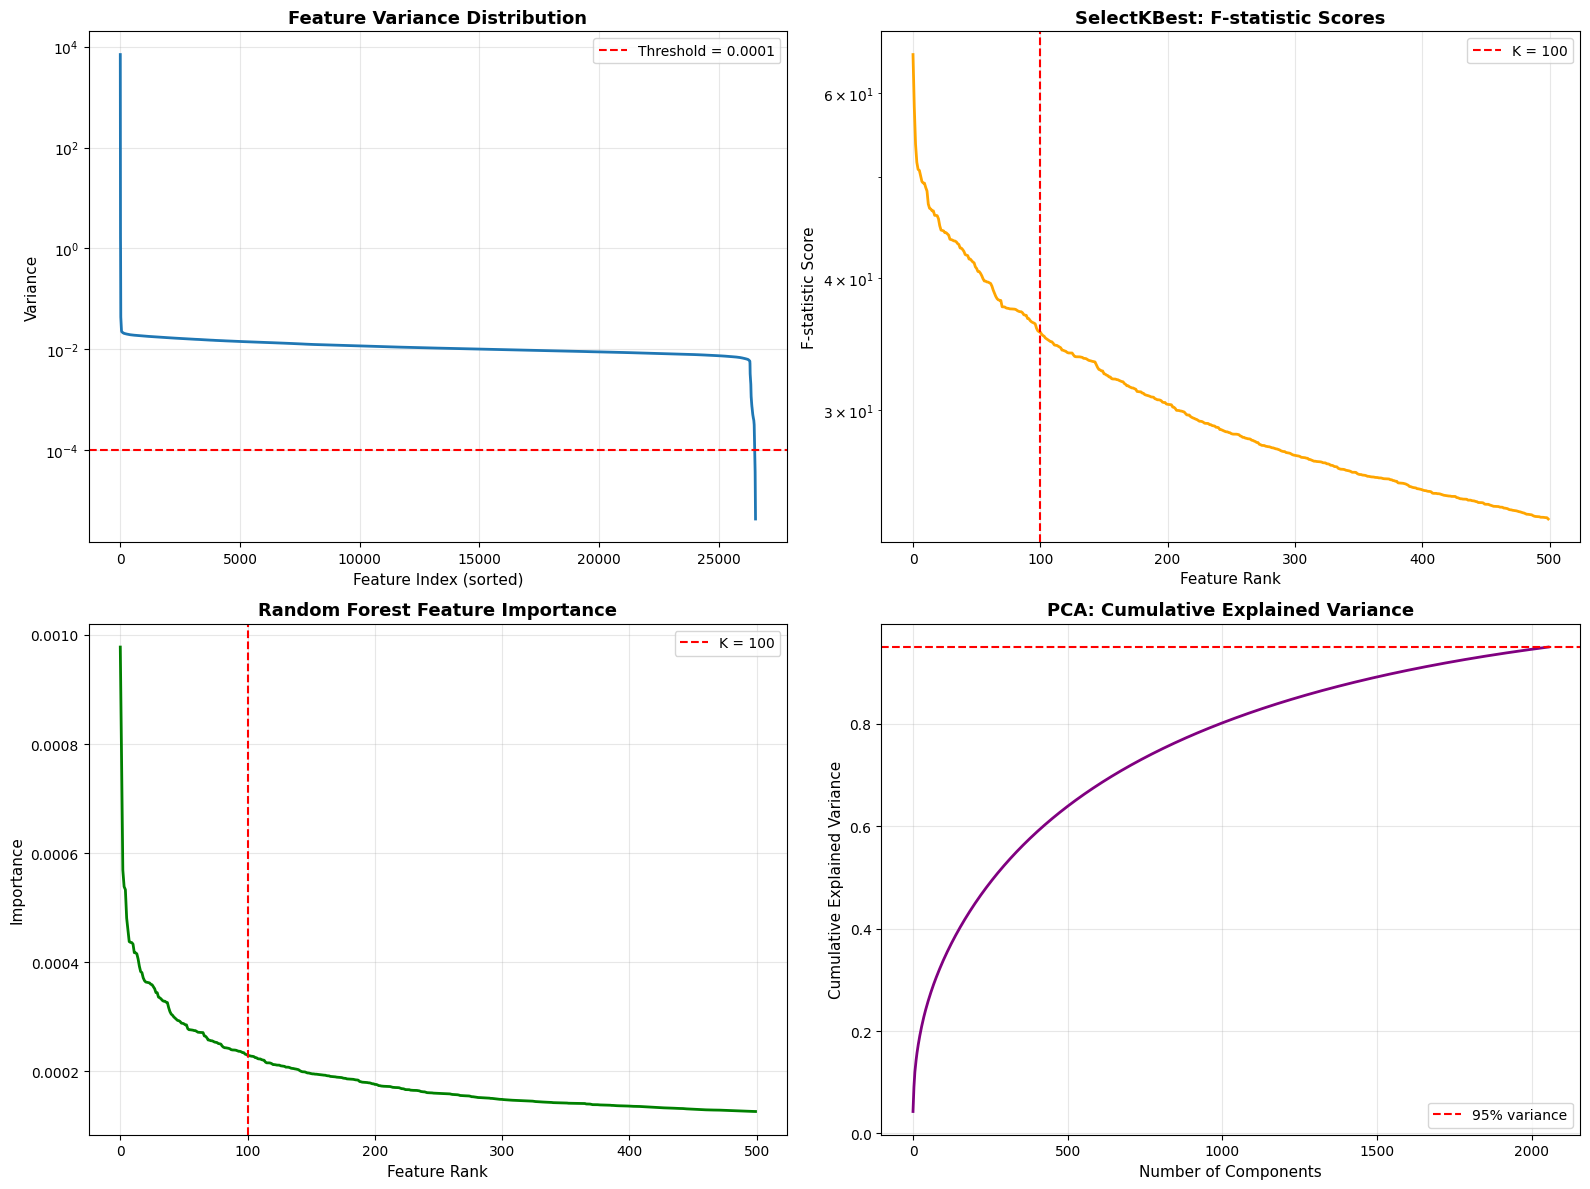


✓ Feature selection visualization saved


In [34]:
# Cell 9: Visualize Feature Selection Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Variance distribution
ax = axes[0, 0]
variances_sorted = np.sort(variances)[::-1]
ax.plot(variances_sorted, linewidth=2)
ax.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
ax.set_xlabel('Feature Index (sorted)', fontsize=11)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Feature Variance Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 2. F-statistic scores
ax = axes[0, 1]
fstat_scores = results_fstat[best_k]['scores']
fstat_scores_sorted = np.sort(fstat_scores)[::-1]
ax.plot(fstat_scores_sorted[:500], linewidth=2, color='orange')
ax.axvline(x=best_k, color='r', linestyle='--', label=f'K = {best_k}')
ax.set_xlabel('Feature Rank', fontsize=11)
ax.set_ylabel('F-statistic Score', fontsize=11)
ax.set_title('SelectKBest: F-statistic Scores', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 3. Random Forest feature importances
ax = axes[1, 0]
importances_sorted = np.sort(importances)[::-1]
ax.plot(importances_sorted[:500], linewidth=2, color='green')
ax.axvline(x=100, color='r', linestyle='--', label='K = 100')
ax.set_xlabel('Feature Rank', fontsize=11)
ax.set_ylabel('Importance', fontsize=11)
ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. PCA explained variance
ax = axes[1, 1]
cumsum_var = np.cumsum(pca_95.explained_variance_ratio_)
ax.plot(cumsum_var, linewidth=2, color='purple')
ax.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax.set_title('PCA: Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "plots" / "feature_selection_comparison.png", 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Feature selection visualization saved")

FEATURE OVERLAP ANALYSIS

Features selected by ALL methods: 3

Pairwise overlaps:
  F-stat & MI: 6
  F-stat & RF: 39
  MI & RF: 28

Sample of features selected by all methods (first 10):
   1. lbp_bin_25
   2. lbp_bin_12
   3. stat_RGB_ch2_iqr


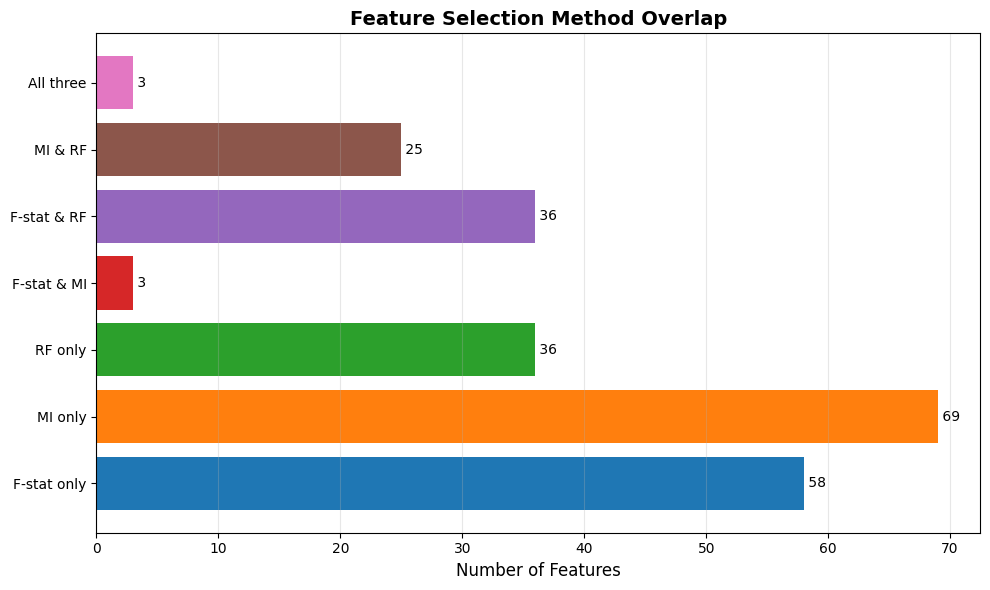

In [35]:
# Cell 10: Compare Feature Overlap Between Methods
print("="*70)
print("FEATURE OVERLAP ANALYSIS")
print("="*70)

# Compare which features are selected by multiple methods
sets = {
    'F-statistic': set(selected_features_fstat),
    'Mutual Info': set(selected_features_mi),
    'Random Forest': set(selected_features_rf)
}

# Common features across all methods
common_all = sets['F-statistic'] & sets['Mutual Info'] & sets['Random Forest']
print(f"\nFeatures selected by ALL methods: {len(common_all)}")

# Pairwise overlaps
print(f"\nPairwise overlaps:")
print(f"  F-stat & MI: {len(sets['F-statistic'] & sets['Mutual Info'])}")
print(f"  F-stat & RF: {len(sets['F-statistic'] & sets['Random Forest'])}")
print(f"  MI & RF: {len(sets['Mutual Info'] & sets['Random Forest'])}")

# Show some common features
if len(common_all) > 0:
    print(f"\nSample of features selected by all methods (first 10):")
    for i, feat in enumerate(list(common_all)[:10], 1):
        print(f"  {i:2d}. {feat}")

# Visualize overlap with Venn-style bar chart
fig, ax = plt.subplots(figsize=(10, 6))
overlap_data = [
    ('F-stat only', len(sets['F-statistic'] - sets['Mutual Info'] - sets['Random Forest'])),
    ('MI only', len(sets['Mutual Info'] - sets['F-statistic'] - sets['Random Forest'])),
    ('RF only', len(sets['Random Forest'] - sets['F-statistic'] - sets['Mutual Info'])),
    ('F-stat & MI', len((sets['F-statistic'] & sets['Mutual Info']) - sets['Random Forest'])),
    ('F-stat & RF', len((sets['F-statistic'] & sets['Random Forest']) - sets['Mutual Info'])),
    ('MI & RF', len((sets['Mutual Info'] & sets['Random Forest']) - sets['F-statistic'])),
    ('All three', len(common_all))
]

labels, values = zip(*overlap_data)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.barh(labels, values, color=colors)
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_title('Feature Selection Method Overlap', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f' {int(width)}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "plots" / "feature_selection_overlap.png", 
            dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Cell 11: Save Selected Features
print("="*70)
print("SAVING SELECTED FEATURES")
print("="*70)

# Save multiple feature selection versions
output_methods = {
    'fstat': (X_train_fstat, X_val_fstat, X_test_fstat, selected_features_fstat),
    'mutual_info': (X_train_mi, X_val_mi, X_test_mi, selected_features_mi),
    'random_forest': (X_train_rf, X_val_rf, X_test_rf, selected_features_rf),
    'pca': (X_train_pca, X_val_pca, X_test_pca, None)
}

for method_name, (X_tr, X_v, X_te, feat_names) in output_methods.items():
    # Create DataFrames
    if feat_names is not None:
        df_tr = pd.DataFrame(X_tr, columns=feat_names)
        df_v = pd.DataFrame(X_v, columns=feat_names)
        df_te = pd.DataFrame(X_te, columns=feat_names)
    else:
        # For PCA, use component names
        comp_names = [f'PC_{i+1}' for i in range(X_tr.shape[1])]
        df_tr = pd.DataFrame(X_tr, columns=comp_names)
        df_v = pd.DataFrame(X_v, columns=comp_names)
        df_te = pd.DataFrame(X_te, columns=comp_names)
    
    # Add labels back
    df_tr['label'] = y_train
    df_v['label'] = y_val
    df_te['label'] = y_test
    
    # Save to CSV
    df_tr.to_csv(FEATURES_DIR / f"features_train_{method_name}.csv", index=False)
    df_v.to_csv(FEATURES_DIR / f"features_val_{method_name}.csv", index=False)
    df_te.to_csv(FEATURES_DIR / f"features_test_{method_name}.csv", index=False)
    
    print(f"\n✓ Saved {method_name} features:")
    print(f"  Train: ({df_tr.shape})")
    print(f"  Val: ({df_v.shape})")
    print(f"  Test: ({df_te.shape})")

# Also save the scalers and selectors for later use
import joblib

models_dir = FEATURES_DIR / "models"
models_dir.mkdir(exist_ok=True, parents=True)

joblib.dump(scaler, models_dir / "scaler.pkl")
joblib.dump(var_selector, models_dir / "variance_selector.pkl")
joblib.dump(fstat_selector, models_dir / "fstat_selector.pkl")
joblib.dump(mi_selector, models_dir / "mi_selector.pkl")
joblib.dump(pca_95, models_dir / "pca_95.pkl")

print(f"\n✓ Saved feature selection models to: {models_dir}")

SAVING SELECTED FEATURES

✓ Saved fstat features:
  Train: ((3909, 101))
  Val: ((285, 101))
  Test: ((297, 101))

✓ Saved mutual_info features:
  Train: ((3909, 101))
  Val: ((285, 101))
  Test: ((297, 101))

✓ Saved random_forest features:
  Train: ((3909, 101))
  Val: ((285, 101))
  Test: ((297, 101))

✓ Saved pca features:
  Train: ((3909, 2055))
  Val: ((285, 2055))
  Test: ((297, 2055))

✓ Saved feature selection models to: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\features\models


In [37]:
# Cell 12: Summary and Recommendations
print("="*70)
print("FEATURE SELECTION SUMMARY")
print("="*70)

summary_data = [
    ('Original Features', X_train.shape[1]),
    ('After Variance Threshold', X_train_var.shape[1]),
    ('SelectKBest (F-stat)', X_train_fstat.shape[1]),
    ('SelectKBest (MI)', X_train_mi.shape[1]),
    ('Random Forest Top-K', X_train_rf.shape[1]),
    ('PCA (95% variance)', X_train_pca.shape[1])
]

print("\nFeature dimensions by method:")
print(f"{'Method':<30} {'Features':>10} {'Reduction':>12}")
print("-" * 54)
original_n = X_train.shape[1]
for method, n_features in summary_data:
    reduction = (1 - n_features/original_n) * 100
    print(f"{method:<30} {n_features:>10} {reduction:>11.1f}%")


FEATURE SELECTION SUMMARY

Feature dimensions by method:
Method                           Features    Reduction
------------------------------------------------------
Original Features                   26543         0.0%
After Variance Threshold            26514         0.1%
SelectKBest (F-stat)                  100        99.6%
SelectKBest (MI)                      100        99.6%
Random Forest Top-K                   100        99.6%
PCA (95% variance)                   2054        92.3%
